# Notebook 05 — Phân tích kinh doanh

**Mục tiêu:** Phân tích tình hình kinh doanh tổng thể

- Revenue, COGS, Gross Profit Margin theo thời gian
- Xác định các vấn đề cốt lõi trong hoạt động kinh doanh
- Phân tích nguyên nhân tiềm ẩn

Tương ứng báo cáo: Phần 2 — Chương 5 (Phân tích kinh doanh và xây dựng giả thuyết)

Phân tích theo 4 cấp độ: Descriptive → Diagnostic → Predictive → Prescriptive

In [ ]:
import sys
sys.path.append('..')   aaaaa

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data_loader import load_processed
from pathlib import Path

FIG_DIR = Path('../outputs/figures/business')
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
%matplotlib inline

In [5]:
sales      = load_processed('sales_clean.csv')
orders     = load_processed('orders_clean.csv')
order_items = load_processed('order_items_clean.csv')
products   = load_processed('products_clean.csv')
returns    = load_processed('returns_clean.csv')
web_traffic = load_processed('web_traffic_clean.csv')
payments   = load_processed('payments_clean.csv')
promotions = load_processed('promotions_clean.csv')

d:\Code\DS_Code\revenue_forecast_ecommerce\notebooks\..\src\data_loader.py:40: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(PROCESSED / subfolder / filename)


## 1. Tổng quan tình hình kinh doanh (Descriptive)

**KPIs cần tính**:
- Total Revenue
- Total Orders
- Average Order Value (AOV)
- Gross Profit Margin (%)

### 1.1. Xu hướng Doanh Thu và Biên lợi nhuận theo thời gian

,Year,Total_Revenue,Total_COGS,Profit_Margin
0,2012,7.414977e+08,5.874619e+08,0.207736
1,2013,1.657169e+09,1.465980e+09,0.115371
2,2014,1.871846e+09,1.574607e+09,0.158794
3,2015,1.889934e+09,1.665442e+09,0.118783
4,2016,2.104641e+09,1.780559e+09,0.153984


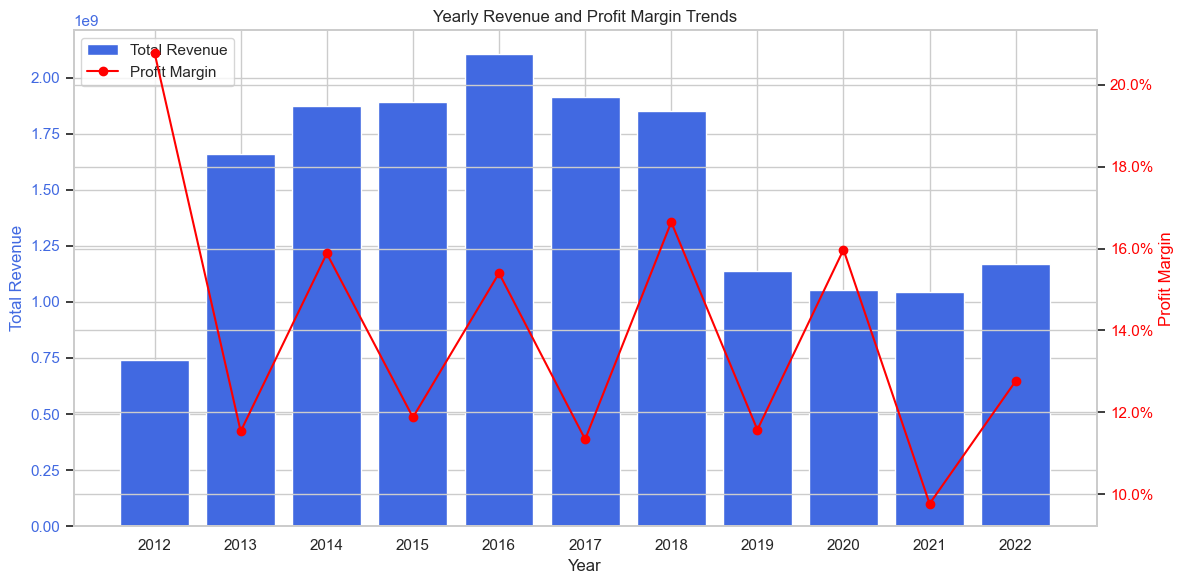

In [6]:
# Parse date column and extract year
sales['date'] = pd.to_datetime(sales['date'], errors='coerce')
sales['Year'] = sales['date'].dt.year

# Calculate yearly revenue and COGS
yearly_sales = sales.groupby('Year').agg(
    Total_Revenue=('revenue', 'sum'),
    Total_COGS=('cogs', 'sum')
).reset_index()

# Calculate profit margin
yearly_sales['Profit_Margin'] = (yearly_sales['Total_Revenue'] - yearly_sales['Total_COGS']) / yearly_sales['Total_Revenue']

display(yearly_sales.head())

yearly_sales = yearly_sales.sort_values('Year')
x = range(len(yearly_sales))

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(x, yearly_sales['Total_Revenue'], color='royalblue', label='Total Revenue')
ax1.set_ylabel('Total Revenue', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticks(x)
ax1.set_xticklabels(yearly_sales['Year'])

ax2 = ax1.twinx()
ax2.plot(x, yearly_sales['Profit_Margin'], color='red', marker='o', label='Profit Margin')
ax2.set_ylabel('Profit Margin', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1))

ax1.set_xlabel('Year')
ax1.set_title('Yearly Revenue and Profit Margin Trends')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()

- Giai đoạn đầu (2012 - 2018) doanh thu tăng rất nhanh, nhưng sau khi đạt đỉnh thì rơi vào trạng thái suy giảm (từ 2019) và chưa phục hồi về nền cũ.
- **Biên lợi nhuận không phát triển tương ứng với doanh thu**: Có năm doanh thu cao nhưng biên lợi nhuận không thật sự vượt trội, ngược lại có năm doanh thu thấp nhưng margin rất tốt. 
- Các cú lên xuống của margin khá gắt.

=> **Biện lợi nhuận biến động qua các năm, đặc biệt có xu hướng giảm mạnh vào các năm lẻ.**

### 1.2. Xu hướng doanh thu theo thời gian

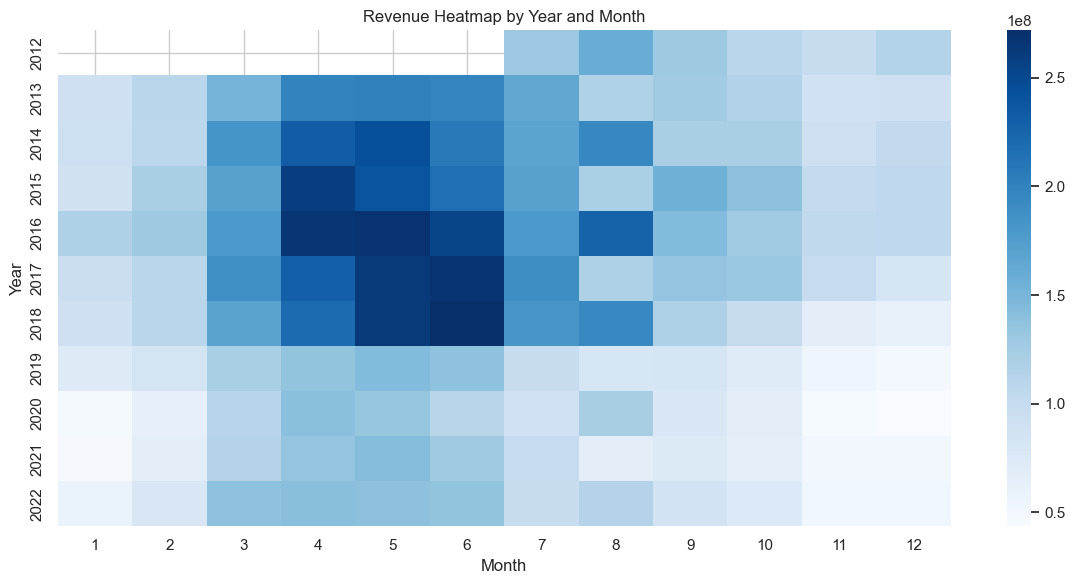

In [7]:
# Parse date column and extract year/month
sales['date'] = pd.to_datetime(sales['date'], errors='coerce')
sales['Year'] = sales['date'].dt.year
sales['Month_Num'] = sales['date'].dt.month

seasonality = sales.groupby(['Year', 'Month_Num'], as_index=False)['revenue'].sum()
heatmap_data = seasonality.pivot(index='Year', columns='Month_Num', values='revenue')

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='Blues', annot=False, fmt='.0f')
plt.title('Revenue Heatmap by Year and Month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

Doanh thu có **mùa vụ khá rõ**. Các **tháng 4–6** thường là giai đoạn doanh thu cao nhất, đặc biệt **giai đoạn 2014–2018**. Trong đó 2016–2018 là cụm năm mạnh nhất, màu đậm tập trung nhiều ở tháng 4, 5, 6.

### 1.3. Doanh thu và Web traffic

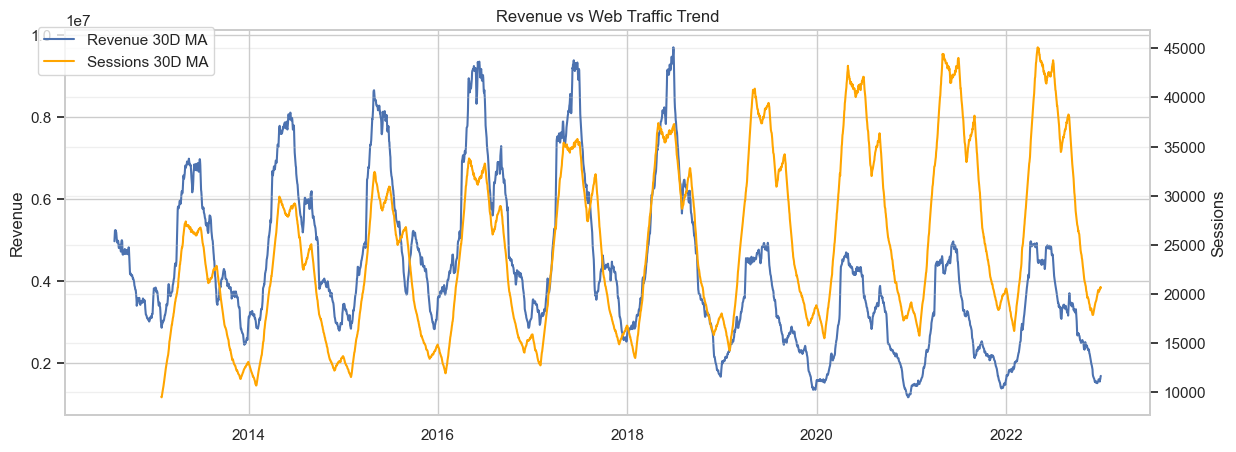

In [8]:
sales['date'] = pd.to_datetime(sales['date'], errors='coerce')
daily_sales = sales.groupby('date', as_index=False)['revenue'].sum()
daily_sales = daily_sales.sort_values('date')
daily_sales['revenue_30D_MA'] = daily_sales['revenue'].rolling(30).mean()
daily_sales['revenue_90D_MA'] = daily_sales['revenue'].rolling(90).mean()
web_traffic['date'] = pd.to_datetime(web_traffic['date'])

traffic_daily = web_traffic.groupby('date', as_index=False).agg(
    sessions=('sessions', 'sum'),
    visitors=('unique_visitors', 'sum')
)

rev_traffic = daily_sales.merge(
    traffic_daily,
    left_on='date',
    right_on='date',
    how='left'
)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(rev_traffic['date'], rev_traffic['revenue_30D_MA'], label='Revenue 30D MA')
ax1.set_ylabel('Revenue')

ax2 = ax1.twinx()
ax2.plot(rev_traffic['date'], rev_traffic['sessions'].rolling(30).mean(), label='Sessions 30D MA', color='orange')
ax2.set_ylabel('Sessions')

plt.title('Revenue vs Web Traffic Trend')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.grid(alpha=0.3)
plt.show()

- Giai đoạn 2013–2018, Revenue 30D MA và Sessions 30D MA đi khá cùng chiều. Mỗi khi traffic tăng theo mùa, doanh thu cũng tăng theo. Điều này cho thấy lúc đó doanh nghiệp còn **chuyển đổi traffic thành doanh thu khá tốt**.
- Nhưng từ khoảng 2019 trở đi, hai đường bắt đầu tách pha rõ rệt: Sessions vẫn tăng mạnh, thậm chí đạt mức cao nhất vào 2020–2022, nhưng Revenue lại giảm và không phục hồi tương ứng. 

**=> Marketing tốt, thu hút KH ổn định, nhưng chưa chuyển hóa được thành doanh thu.**

### 1.4. Order và AOV

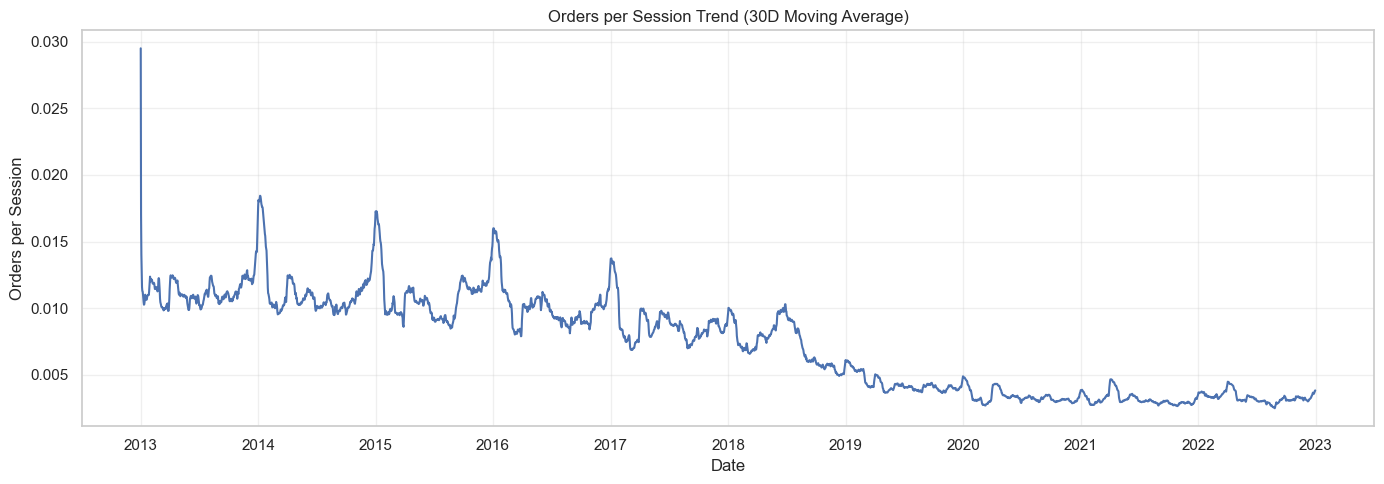

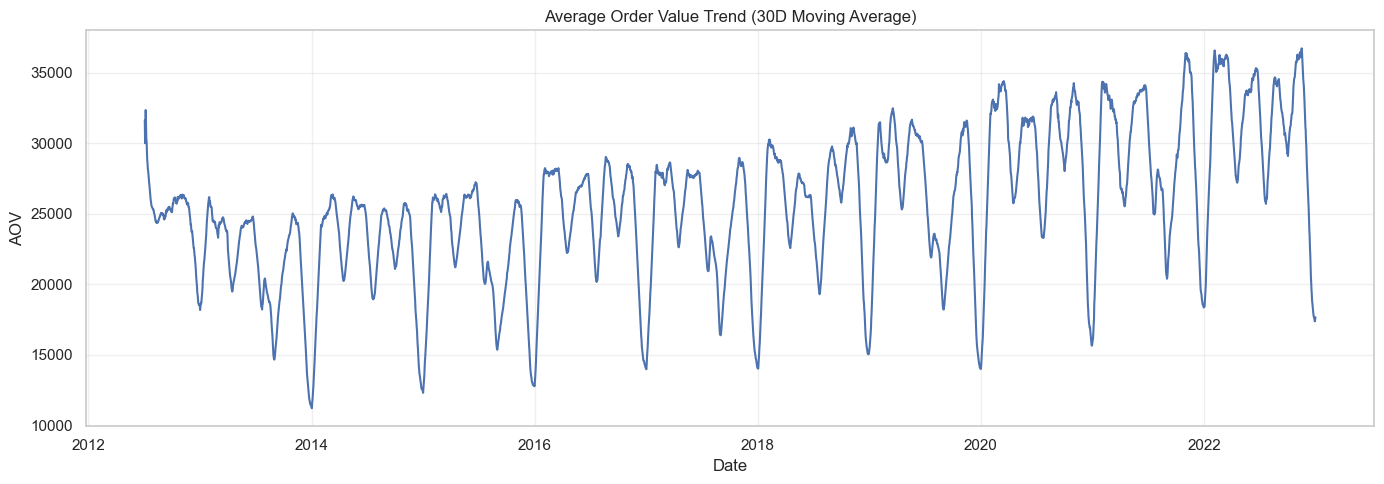

In [9]:
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
web_traffic['date'] = pd.to_datetime(web_traffic['date'], errors='coerce')

traffic_daily = web_traffic.groupby('date', as_index=False).agg(
    sessions=('sessions', 'sum'),
    visitors=('unique_visitors', 'sum')
)

daily_orders = orders.groupby('order_date', as_index=False).agg(
    Orders=('order_id', 'nunique')
)

funnel = rev_traffic.merge(
    daily_orders,
    left_on='date',
    right_on='order_date',
    how='left'
)

funnel['Orders'] = funnel['Orders'].fillna(0)
funnel['Orders_per_Session'] = np.where(
    funnel['sessions'] > 0,
    funnel['Orders'] / funnel['sessions'],
    np.nan
)
funnel['OPS_30D_MA'] = funnel['Orders_per_Session'].rolling(30, min_periods=1).mean()
funnel['Year'] = funnel['date'].dt.year

plt.figure(figsize=(14, 5))
plt.plot(funnel['date'], funnel['OPS_30D_MA'])
plt.title('Orders per Session Trend (30D Moving Average)')
plt.xlabel('Date')
plt.ylabel('Orders per Session')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

yearly_funnel = funnel.groupby('Year', as_index=False)['Orders_per_Session'].mean()

payments_orders = payments.merge(
    orders[['order_id', 'order_date', 'order_status']],
    on='order_id',
    how='left'
)

daily_aov = payments_orders.groupby('order_date', as_index=False).agg(
    Orders=('order_id', 'nunique'),
    Payment_Value=('payment_value', 'sum')
)

daily_aov['AOV'] = daily_aov['Payment_Value'] / daily_aov['Orders']
daily_aov['AOV_30D_MA'] = daily_aov['AOV'].rolling(30, min_periods=1).mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_aov['order_date'], daily_aov['AOV_30D_MA'])
plt.title('Average Order Value Trend (30D Moving Average)')
plt.xlabel('Date')
plt.ylabel('AOV')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Số lượng Orders giảm dần và giảm mạnh sau 2019 nhưng AOV lại tăng.
**⇒ Số đơn tạo ra trên mỗi session giảm quá mạnh, và mức tăng AOV không đủ bù lại sự suy giảm conversion.**

### 1.5. Chất lượng traffic giữa các nguồn

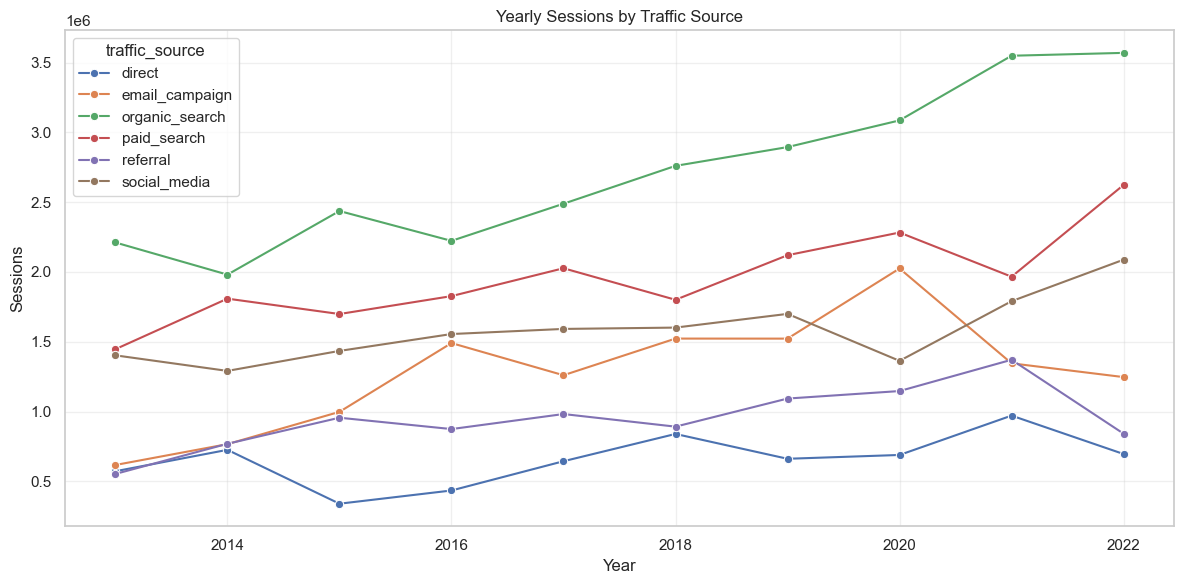

In [10]:
web_traffic['date'] = pd.to_datetime(web_traffic['date'])
web_traffic['Year'] = web_traffic['date'].dt.year

source_yearly = web_traffic.groupby(['Year', 'traffic_source'], as_index=False)['sessions'].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=source_yearly,
    x='Year',
    y='sessions',
    hue='traffic_source',
    marker='o'
)

plt.title('Yearly Sessions by Traffic Source')
plt.xlabel('Year')
plt.ylabel('Sessions')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Organic là nguồn lớn nhất, các nguồn traffic khác  đều tăng hoặc nhiến động không nhiều.


In [11]:
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
web_traffic['date'] = pd.to_datetime(web_traffic['date'], errors='coerce')

orders_with_year = orders.assign(Year=orders['order_date'].dt.year).rename(columns={'order_source': 'traffic_source'})
order_items_with_orders = order_items.merge(
    orders_with_year[['order_id', 'Year', 'traffic_source']],
    on='order_id',
    how='left'
)

orders_cat_source = order_items_with_orders.groupby(['Year', 'traffic_source'], as_index=False).agg(
    orders=('order_id', 'nunique'),
    quantity=('quantity', 'sum')
)

sessions_source_year = web_traffic.assign(Year=web_traffic['date'].dt.year).groupby(
    ['Year', 'traffic_source'],
    as_index=False
).agg(
    sessions=('sessions', 'sum')
)

cat_source_conv = orders_cat_source.merge(
    sessions_source_year,
    on=['Year', 'traffic_source'],
    how='left'
)

cat_source_conv['orders_per_session'] = np.where(
    cat_source_conv['sessions'] > 0,
    cat_source_conv['orders'] / cat_source_conv['sessions'],
    np.nan
)

cat_source_conv['quantity_per_session'] = np.where(
    cat_source_conv['sessions'] > 0,
    cat_source_conv['quantity'] / cat_source_conv['sessions'],
    np.nan
)

display(cat_source_conv.head())

,Year,traffic_source,orders,quantity,sessions,orders_per_session,quantity_per_session
0,2012,direct,2509,12778,NaN,NaN,NaN
1,2012,email_campaign,3879,20105,NaN,NaN,NaN
2,2012,organic_search,9021,46724,NaN,NaN,NaN
3,2012,paid_search,6984,36488,NaN,NaN,NaN
4,2012,referral,3209,16724,NaN,NaN,NaN


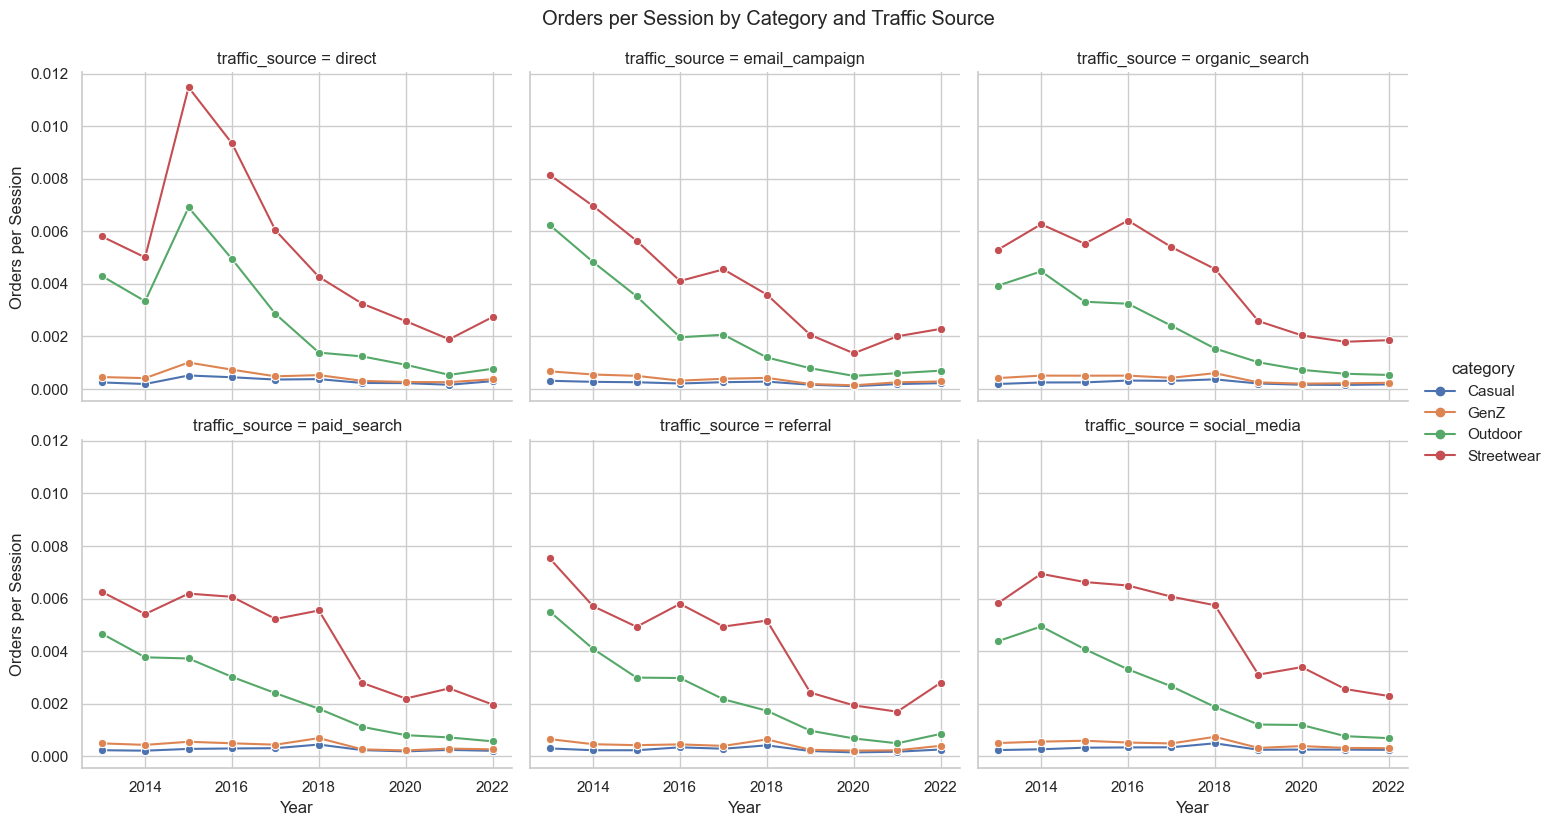

In [12]:
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
web_traffic['date'] = pd.to_datetime(web_traffic['date'], errors='coerce')

orders_with_year = orders.assign(Year=orders['order_date'].dt.year).rename(columns={'order_source': 'traffic_source'})
order_items_with_category = order_items.merge(
    products[['product_id', 'category']],
    on='product_id',
    how='left'
)
order_items_with_orders = order_items_with_category.merge(
    orders_with_year[['order_id', 'Year', 'traffic_source']],
    on='order_id',
    how='left'
)

orders_cat_source = order_items_with_orders.groupby(['Year', 'traffic_source', 'category'], as_index=False).agg(
    orders=('order_id', 'nunique'),
    quantity=('quantity', 'sum')
)

sessions_source_year = web_traffic.assign(Year=web_traffic['date'].dt.year).groupby(
    ['Year', 'traffic_source'],
    as_index=False
).agg(
    sessions=('sessions', 'sum')
)

cat_source_conv = orders_cat_source.merge(
    sessions_source_year,
    on=['Year', 'traffic_source'],
    how='left'
)

cat_source_conv['orders_per_session'] = np.where(
    cat_source_conv['sessions'] > 0,
    cat_source_conv['orders'] / cat_source_conv['sessions'],
    np.nan
)

cat_source_conv['quantity_per_session'] = np.where(
    cat_source_conv['sessions'] > 0,
    cat_source_conv['quantity'] / cat_source_conv['sessions'],
    np.nan
)

g = sns.relplot(
    data=cat_source_conv,
    x='Year',
    y='orders_per_session',
    hue='category',
    col='traffic_source',
    col_wrap=3,
    kind='line',
    marker='o',
    height=4,
    aspect=1.2
)

g.fig.suptitle('Orders per Session by Category and Traffic Source', y=1.03)
g.set_axis_labels('Year', 'Orders per Session')
plt.show()

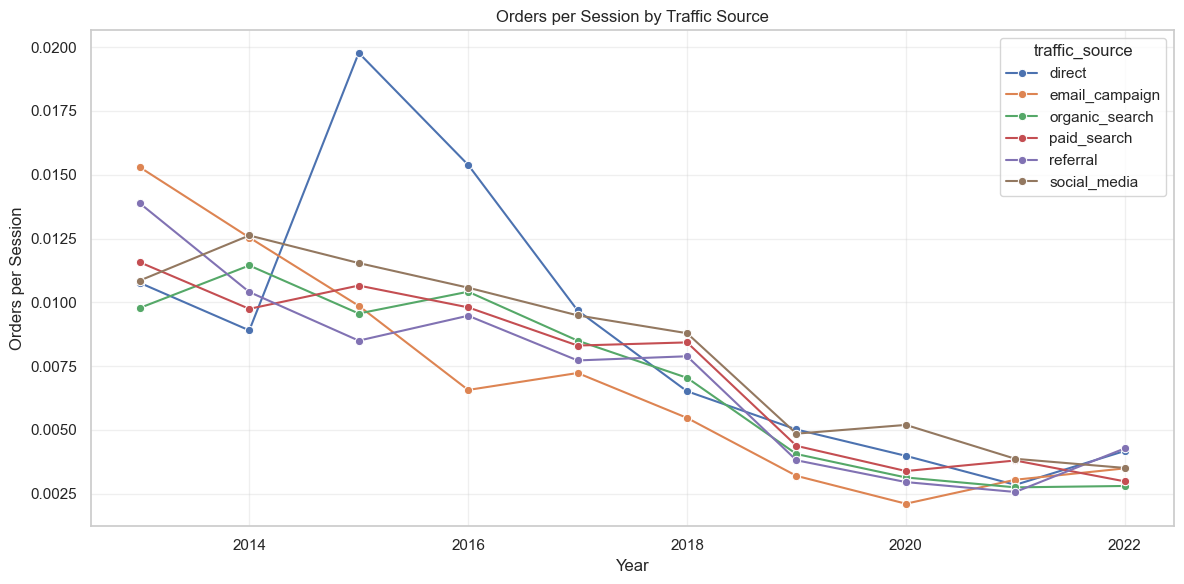

In [13]:
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
web_traffic['date'] = pd.to_datetime(web_traffic['date'], errors='coerce')

traffic_source = web_traffic.assign(Year=web_traffic['date'].dt.year).groupby(['Year', 'traffic_source'], as_index=False).agg(
    sessions=('sessions', 'sum')
)

orders_source = orders.assign(
    Year=orders['order_date'].dt.year
).groupby(['Year', 'order_source'], as_index=False).agg(
    orders=('order_id', 'nunique')
).rename(columns={'order_source': 'traffic_source'})

conv_source = traffic_source.merge(
    orders_source,
    on=['Year', 'traffic_source'],
    how='left'
)

conv_source['orders'] = conv_source['orders'].fillna(0)
conv_source['orders_per_session'] = np.where(
    conv_source['sessions'] > 0,
    conv_source['orders'] / conv_source['sessions'],
    np.nan
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=conv_source,
    x='Year',
    y='orders_per_session',
    hue='traffic_source',
    marker='o'
)

plt.title('Orders per Session by Traffic Source')
plt.xlabel('Year')
plt.ylabel('Orders per Session')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Suy giảm CR toàn bộ traffic source, không phải một nguồn riêng lẻ 
**=> Vấn đề hệ thống.**
Giảm mạnh ở Streetwear, Outdoor. Nhìn vào cũng thấy, doanh nghiệp đang phụ thuộc mạnh vào 1 nhóm danh mục chủ lực. 

### 1.6. Lý do trả hàng

,return_reason,count,share
0,wrong_size,13967,0.349708
1,defective,8020,0.200806
2,not_as_described,7035,0.176144
3,changed_mind,6931,0.173540
4,late_delivery,3986,0.099802


C:\Users\PC\AppData\Local\Temp\ipykernel_104648\192680309.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=return_reason_stats, y='return_reason', x='count', palette='Blues_r')


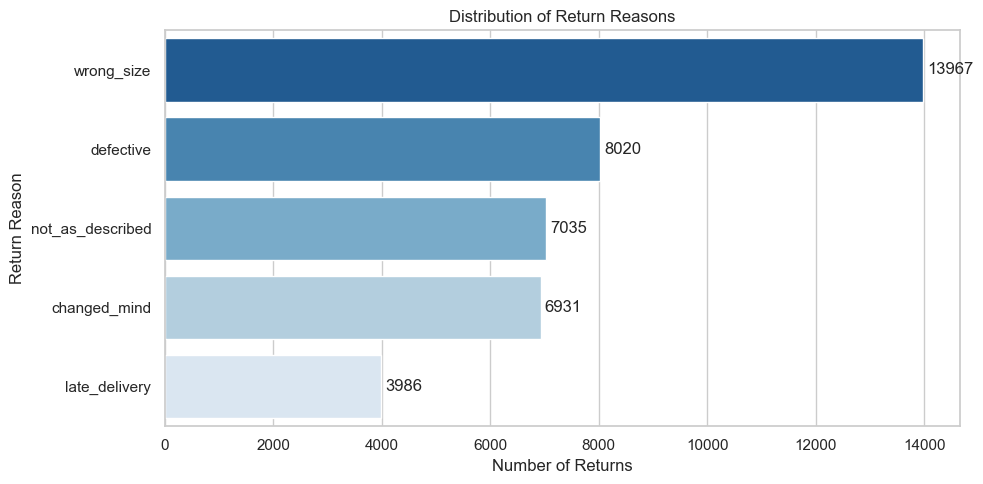

In [14]:
# Thống kê lý do trả hàng
return_reason_stats = (
    returns['return_reason']
    .fillna('unknown')
    .str.strip()
    .str.lower()
    .value_counts()
    .reset_index()
)
return_reason_stats.columns = ['return_reason', 'count']
return_reason_stats['share'] = return_reason_stats['count'] / return_reason_stats['count'].sum()

display(return_reason_stats)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=return_reason_stats, y='return_reason', x='count', palette='Blues_r')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

ax.set_title('Distribution of Return Reasons')
ax.set_xlabel('Number of Returns')
ax.set_ylabel('Return Reason')
plt.tight_layout()
plt.show()

Trong các lý do trả hàng, **sai kích cỡ** là lý do có số lượng chiếm nhiều nhất. Cao gấp đôi so với các lý do còn lại => Doanh nghiệp đang gặp vấn đề sản phẩm.

## 2. Câu hỏi kinh doanh

1. Vì sao năm 2019 lại là điểm gãy doanh thu?

2. Vì sao biên lợi nhuận thay đổi bất thường và không đồng nhất với doanh thu? 

3. Vì sao traffic tăng nhưng doanh thu lại giảm ở năm 2019? Tỷ lệ conversion giảm?

4. Vì sao Orders giảm nhưng AOV lại tăng?

5. Tại sao “Wrong size” là lý do trả hàng nhiều nhất và Web traffic dù lượt truy cập ổn định nhưng không chốt deal dc?


## 3. Phân tích các vấn đề cốt lõi (Diagnostic)

- Vấn đề 1. Revenue giảm vì conversion giảm, bằng chứng ở các biểu đồ tổng quan

- Vấn đề 2. AOV tăng là tín hiệu sản phẩm bị đẩy giá, không hẳn là tín hiệu tốt

- Vấn đề 3. Conversion rate giảm, nguyên nhân từ đâu?

**Vấn đề chung lớn nhất:** Công thức tính Doanh thu của doanh nghiệp:
=> Revenue=Sessions×Conversion Rate×AOV

Mà Sessions tăng, AOV tăng, nhưng Orders (CR) giảm mạnh => kéo sập Revenue chính là: **Orders per Session.**


### 3.1. Vì sao năm 2019 là điểm gãy doanh thu?

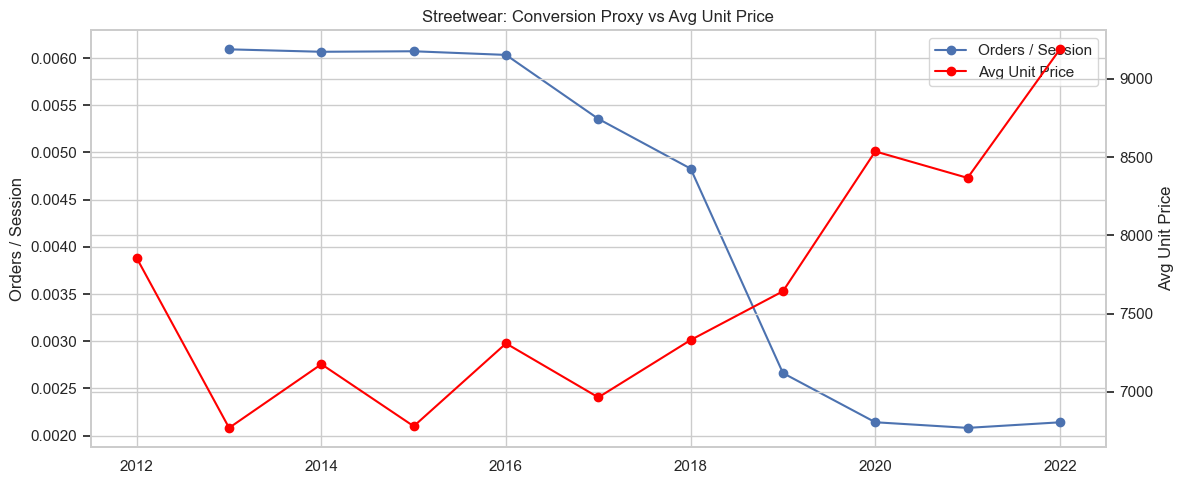

In [15]:
order_items_with_category = order_items.merge(
    products[['product_id', 'category', 'cogs']],
    on='product_id',
    how='left'
)

order_items_with_orders = order_items_with_category.merge(
    orders[['order_id', 'order_date', 'order_source']],
    on='order_id',
    how='left'
)

order_items_with_orders['order_date'] = pd.to_datetime(order_items_with_orders['order_date'], errors='coerce')
valid_items = order_items_with_orders.copy()
valid_items['Year'] = valid_items['order_date'].dt.year
valid_items['gross_revenue'] = valid_items['quantity'] * valid_items['unit_price'] - valid_items['discount_amount'].fillna(0)
valid_items['gross_profit'] = valid_items['gross_revenue'] - (valid_items['quantity'] * valid_items['cogs'])

sessions_year = web_traffic.copy()
sessions_year['date'] = pd.to_datetime(sessions_year['date'], errors='coerce')
sessions_year['Year'] = sessions_year['date'].dt.year
sessions_year = sessions_year.groupby('Year', as_index=False).agg(
    sessions=('sessions', 'sum')
)

street = valid_items[valid_items['category'] == 'Streetwear'].copy()

street_year = street.groupby('Year', as_index=False).agg(
    orders=('order_id', 'nunique'),
    quantity=('quantity', 'sum'),
    revenue=('gross_revenue', 'sum'),
    profit=('gross_profit', 'sum'),
    avg_unit_price=('unit_price', 'mean'),
    discount=('discount_amount', 'sum')
)

street_year = street_year.merge(sessions_year, on='Year', how='left')
street_year['orders_per_session'] = street_year['orders'] / street_year['sessions']
street_year['revenue_per_session'] = street_year['revenue'] / street_year['sessions']
street_year['profit_per_session'] = street_year['profit'] / street_year['sessions']
street_year['discount_rate'] = street_year['discount'] / (street_year['revenue'] + street_year['discount'])
street_year['items_per_order'] = street_year['quantity'] / street_year['orders']

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(street_year['Year'], street_year['orders_per_session'], marker='o', label='Orders / Session')
ax1.set_ylabel('Orders / Session')

ax2 = ax1.twinx()
ax2.plot(street_year['Year'], street_year['avg_unit_price'], marker='o', color='red', label='Avg Unit Price')
ax2.set_ylabel('Avg Unit Price')

plt.title('Streetwear: Conversion Proxy vs Avg Unit Price')
h1,l1 = ax1.get_legend_handles_labels()
h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2)
plt.tight_layout()
plt.show()

Như đã phân tích từ Notebook 03 (Sản phẩm), công ty phụ thuộc quá nhiều vào 1 sản phẩm chủ lực là Streetwear. => Từ năm 2019, **tăng mạnh giá streetwear** dẫn tới giảm volume, tạo ra điểm gãy doanh thu lớn nhất.


### 3.2. Vì sao biên lợi nhuận thay đổi bất thường và không đồng nhất với doanh thu? 

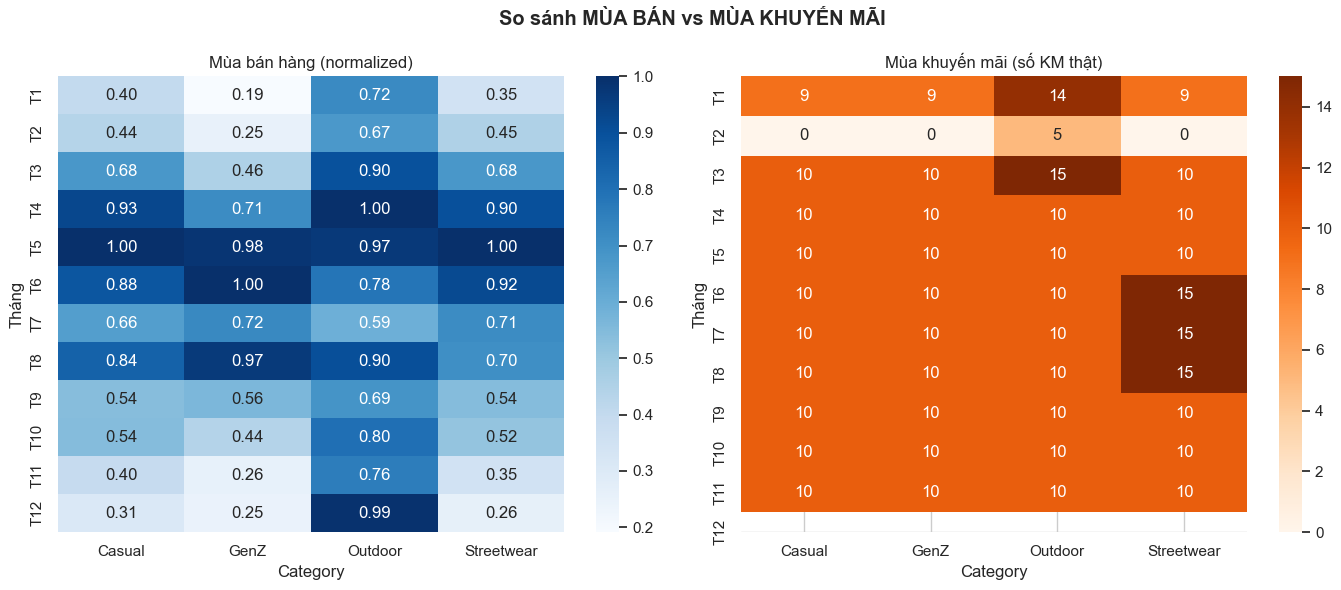

In [16]:
orders = orders.copy()
order_items = order_items.copy()
products = products.copy()
promotions = promotions.copy()

# =========================
# 1. DOANH THU THEO THÁNG × CATEGORY
# =========================
oi = order_items.merge(
    orders[['order_id', 'order_date']],
    on='order_id',
    how='left'
)

oi = oi.merge(
    products[['product_id', 'category']],
    on='product_id',
    how='left'
)

oi['order_date'] = pd.to_datetime(oi['order_date'], errors='coerce')
oi['month'] = oi['order_date'].dt.month

# Nếu chưa có revenue thì tự tính
if 'revenue' not in oi.columns:
    oi['revenue'] = oi['unit_price'] * oi['quantity'] - oi.get('discount_amount', 0)

rev_month = oi.groupby(['month', 'category'])['revenue'].sum().unstack().fillna(0)

# Normalize để thấy pattern mùa
rev_norm = rev_month.div(rev_month.max())

# =========================
# 2. KM THEO THÁNG × CATEGORY (CHUẨN)
# =========================

# Convert date
promotions['start_date'] = pd.to_datetime(promotions['start_date'], errors='coerce')
promotions['end_date'] = pd.to_datetime(promotions['end_date'], errors='coerce')

# Join promotions với order_items để biết category
promo_items = order_items.merge(
    promotions[['promo_id', 'start_date', 'end_date']],
    on='promo_id',
    how='inner'
)

promo_items = promo_items.merge(
    products[['product_id', 'category']],
    on='product_id',
    how='left'
)

# Expand ra từng tháng KM chạy
promo_months = []

for _, row in promo_items.iterrows():
    if pd.isna(row['start_date']) or pd.isna(row['end_date']):
        continue

    months = pd.period_range(
        start=row['start_date'].to_period('M'),
        end=row['end_date'].to_period('M'),
        freq='M'
    )

    for m in months:
        promo_months.append({
            'month': m.month,
            'category': row['category'],
            'promo_id': row['promo_id']
        })

promo_df = pd.DataFrame(promo_months)

# Đếm số KM thực sự theo tháng
if not promo_df.empty:
    promo_month = promo_df.groupby(['month', 'category'])['promo_id'].nunique().unstack().fillna(0)
else:
    promo_month = pd.DataFrame(index=range(1, 13))

# =========================
# 3. VẼ HEATMAP
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Doanh thu
sns.heatmap(
    rev_norm,
    cmap='Blues',
    annot=True,
    fmt='.2f',
    ax=axes[0],
    yticklabels=[f'T{i}' for i in range(1, 13)]
)

axes[0].set_title('Mùa bán hàng (normalized)')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Tháng')

# Khuyến mãi 
if not promo_month.empty:
    sns.heatmap(
        promo_month,
        cmap='Oranges',
        annot=True,
        fmt='.0f',
        ax=axes[1],
        yticklabels=[f'T{i}' for i in range(1, 13)]
    )
else:
    axes[1].set_axis_off()
    axes[1].set_title('Mùa khuyến mãi (không có dữ liệu)')

axes[1].set_title('Mùa khuyến mãi (số KM thật)')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Tháng')

plt.suptitle('So sánh MÙA BÁN vs MÙA KHUYẾN MÃI', fontweight='bold')
plt.tight_layout()
plt.show()

Dữ liệu tổng doanh thu và tổng số khuyến mãi theo tháng:


,month,total_revenue,total_promotions,month_name
0,1,7.964305e+08,41.0,Jan
1,2,9.692912e+08,5.0,Feb
2,3,1.433761e+09,45.0,Mar
3,4,1.859505e+09,40.0,Apr
4,5,2.038379e+09,0.0,May
5,6,1.852845e+09,40.0,Jun
6,7,1.429122e+09,45.0,Jul
7,8,1.508954e+09,45.0,Aug
8,9,1.148765e+09,45.0,Sep
9,10,1.122944e+09,40.0,Oct


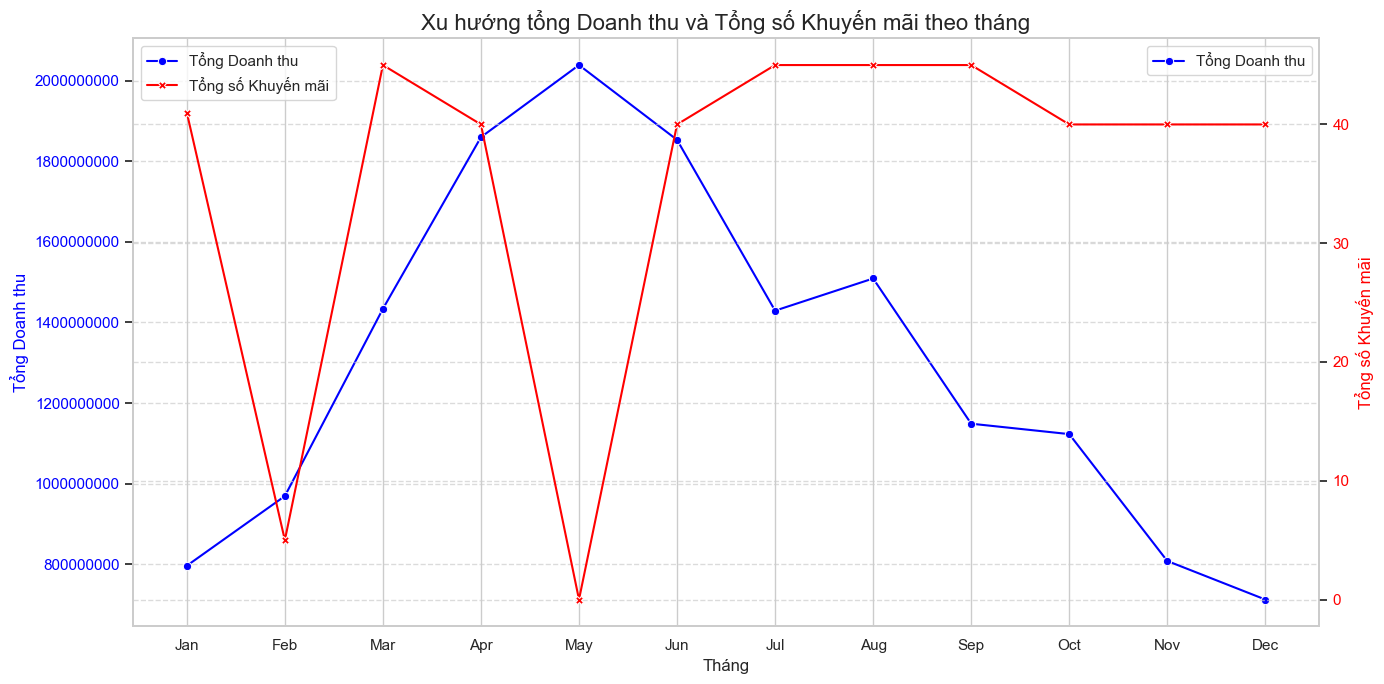

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import datetime

# Compute total monthly revenue. Build a safe series regardless of input type.
if isinstance(rev_month, pd.DataFrame):
    total_series = rev_month.sum(axis=1)
else:
    total_series = rev_month.copy()

# Extract month numbers from the index robustly
try:
    months_idx = total_series.index.astype(int)
except Exception:
    try:
        months_idx = pd.to_datetime(total_series.index).month
    except Exception:
        months_idx = list(range(1, len(total_series) + 1))

total_monthly_revenue = pd.DataFrame({
    'month': list(months_idx),
    'total_revenue': list(total_series.values)
})

# Compute total monthly promotions. Handle empty promo_month gracefully.
if isinstance(promo_month, pd.DataFrame) and not promo_month.empty:
    promo_series = promo_month.sum(axis=1)
    try:
        promo_months_idx = promo_series.index.astype(int)
    except Exception:
        try:
            promo_months_idx = pd.to_datetime(promo_series.index).month
        except Exception:
            promo_months_idx = list(range(1, len(promo_series) + 1))

    total_monthly_promotions = pd.DataFrame({
        'month': list(promo_months_idx),
        'total_promotions': list(promo_series.values)
    })
else:
    total_monthly_promotions = pd.DataFrame({'month': list(range(1, 13)), 'total_promotions': 0})

# Merge these two dataframes and fill missing values
monthly_summary = pd.merge(total_monthly_revenue, total_monthly_promotions, on='month', how='outer')
monthly_summary['total_revenue'] = monthly_summary['total_revenue'].fillna(0)
monthly_summary['total_promotions'] = monthly_summary['total_promotions'].fillna(0)

# Ensure month is integer and sorted
monthly_summary['month'] = monthly_summary['month'].astype(int)
monthly_summary = monthly_summary.sort_values('month').reset_index(drop=True)

# Map month number to abbreviated month name and keep correct order
month_order = [datetime.date(1900, m, 1).strftime('%b') for m in range(1, 13)]
monthly_summary['month_name'] = monthly_summary['month'].apply(lambda x: datetime.date(1900, x, 1).strftime('%b'))

print("Dữ liệu tổng doanh thu và tổng số khuyến mãi theo tháng:")
display(monthly_summary)

# Create the plot (use numeric month for x to preserve ordering)
fig, ax1 = plt.subplots(figsize=(14, 7))

sns.lineplot(x='month', y='total_revenue', data=monthly_summary, marker='o', color='blue', ax=ax1, label='Tổng Doanh thu')
ax1.set_xlabel('Tháng', fontsize=12)
ax1.set_ylabel('Tổng Doanh thu', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.ticklabel_format(style='plain', axis='y')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.set_xticks(list(range(1, 13)))
ax1.set_xticklabels(month_order)

# Second axis for promotions
ax2 = ax1.twinx()
sns.lineplot(x='month', y='total_promotions', data=monthly_summary, marker='X', color='red', ax=ax2, label='Tổng số Khuyến mãi')
ax2.set_ylabel('Tổng số Khuyến mãi', color='red', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Xu hướng tổng Doanh thu và Tổng số Khuyến mãi theo tháng', fontsize=16)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

# Phân tích chiến lược khuyến mãi & Profit Margin

1. Sai lệch về timing khuyến mãi: Khuyến mãi không được triển khai vào đúng thời điểm nhu cầu cao nhất. T5 hoàn toàn không có KM dù doanh thu tăng mạnh, trong khi T7–T9 vẫn duy trì nhiều chương trình dù nhu cầu đã giảm, làm discount cost tăng nhưng không tạo thêm tăng trưởng, từ đó kéo giảm profit margin.

2. Chiến lược khuyến mãi dàn trải: Khuyến mãi được triển khai gần như xuyên suốt năm và cho nhiều danh mục cùng lúc thay vì tập trung vào các giai đoạn chiến lược. Ví dụ T2 chỉ có 5 chương trình Rural Special nên không đủ tạo hiệu ứng doanh thu rõ rệt.

3. Hiệu quả khuyến mãi phụ thuộc mạnh vào timing: T3 đẩy mạnh khuyến mãi giúp doanh thu T4–T5 tăng mạnh, cho thấy tồn tại hiệu ứng trễ. Ngược lại, T7–T9 vẫn có nhiều khuyến mãi nhưng doanh thu tiếp tục giảm, chứng minh khuyến mãi chỉ hiệu quả khi đi trước nhu cầu thị trường.

4. Các năm lẻ có biên lợi nhuận yếu hơn: Năm lẻ triển khai thêm Urban và Rural cho Streetwear và Outdoor, làm tăng mức độ discount. Urban là chương trình clearance diễn ra từ 30/08–02/09 và trùng với Fall Launch, có thể khiến khách hàng ưu tiên hàng giảm giá thay vì collection mới, từ đó làm giảm tỷ lệ bán full-price và kéo giảm margin.

5. Tăng giá để bù margin tạo phản ứng ngược: Sau 2017, Streetwear và Outdoor bắt đầu tăng giá để bù lượng đơn hàng giảm. Tuy nhiên điều này lại mâu thuẫn với mục tiêu clearance là bán nhanh với giá thấp để thu hồi vốn, đồng thời có thể làm conversion rate và số lượng đơn tiếp tục giảm.

6. Các năm chẵn chưa có đổi mới về khuyến mãi: So với năm lẻ, năm chẵn không có thêm chương trình mới đáng kể, khiến chiến lược promotion trở nên lặp lại và thiếu động lực tăng trưởng dài hạn.


**=> Biên lợi nhuận ở các năm lẻ suy yếu chủ yếu do doanh nghiệp tăng cường khuyến mãi nhưng chưa tối ưu về timing và chiến lược triển khai. Việc discount kéo dài, clearance chồng chéo với launch campaign và tăng giá để bù margin khiến doanh thu không tăng đủ để bù lại phần lợi nhuận bị mất.**

### 3.3. Vì sao traffic tăng nhưng doanh thu lại giảm ở năm 2019? Tỷ lệ conversion giảm?

Ma trận đếm số lượng sản phẩm theo Kích cỡ và Màu sắc:


color,black,blue,green,orange,pink,purple,red,silver,white,yellow
size,,,,,,,,,,
L,0,0,121,121,120,0,121,0,120,0
M,121,120,0,0,0,121,0,120,0,121
S,0,0,120,121,121,0,120,0,121,0
XL,121,121,0,0,0,120,0,121,0,120


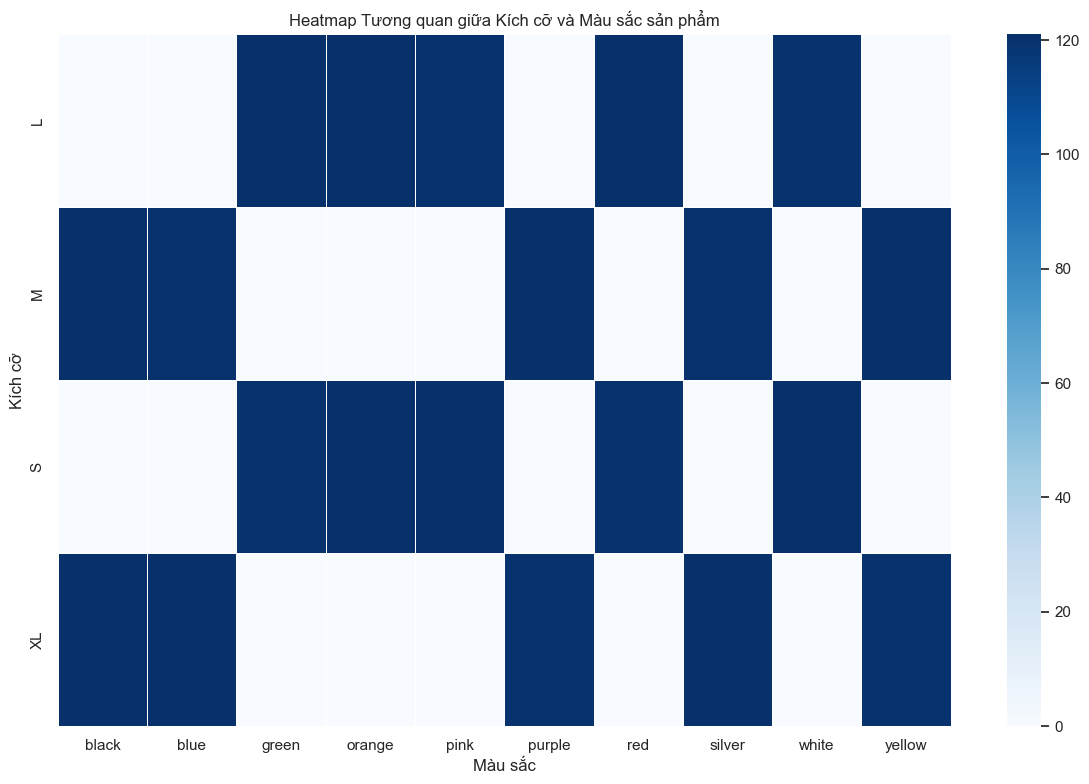

In [21]:
# copy dataframe
products_df = products.copy()

# tạo ma trận size-color
size_color_counts = (
    products_df
    .groupby(['size', 'color'])
    .size()
    .unstack(fill_value=0)
)

print("Ma trận đếm số lượng sản phẩm theo Kích cỡ và Màu sắc:")
display(size_color_counts.head())

# vẽ heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    size_color_counts,
    annot=False,
    cmap='Blues',
    linewidths=.5
)

plt.title('Heatmap Tương quan giữa Kích cỡ và Màu sắc sản phẩm')
plt.xlabel('Màu sắc')
plt.ylabel('Kích cỡ')

plt.tight_layout()
plt.show()

Phân tích cho thấy doanh nghiệp đang áp dụng cơ chế **“khóa màu theo size”**, tức mỗi nhóm kích cỡ chỉ được bán với một tập màu cố định thay vì cho phép toàn bộ màu xuất hiện ở mọi size.

- **Size L và S** chỉ bán các màu: `green`, `orange`, `pink`, `red`, `white`.
- **Size XL và M** chỉ bán các màu: `black`, `blue`, `purple`, `silver`, `yellow`.

### Tác động

- Giảm khả năng khách hàng tìm được đúng combination **size + màu** mong muốn.
- Làm giảm trải nghiệm mua hàng và tỷ lệ conversion.
- Có thể là nguyên nhân khiến **“Wrong size”** trở thành lý do trả hàng phổ biến nhất.
- Dù web traffic ổn định, khách hàng vẫn khó chốt đơn do lựa chọn sản phẩm bị giới hạn.

### 3.4. Vì sao Orders giảm nhưng AOV lại tăng?

=> Do tăng giá

### 3.5. Tại sao “Wrong size” là lý do trả hàng nhiều nhất và Web traffic dù lượt truy cập ổn định nhưng không chốt deal dc?

=> Khóa màu theo Size

## 4. Phân tích nguyên nhân tiềm ẩn

1. Vấn đề: **Doanh thu xuất hiện điểm gãy từ năm 2019** dù traffic vẫn tăng.  
→ Nguyên nhân tiềm ẩn: Công ty phụ thuộc quá nhiều vào **Streetwear** – danh mục chủ lực. Từ 2019, doanh nghiệp bắt đầu **tăng giá** để bù margin khiến **volume đơn hàng giảm**, kéo theo **conversion rate suy yếu** và doanh thu giảm mạnh.

2. Vấn đề: **Biên lợi nhuận biến động bất thường** và không đồng nhất với doanh thu.  
→ Nguyên nhân tiềm ẩn: Các chương trình **Promotion** được triển khai dàn trải, sai timing và kéo dài quá mức. **Discount cost** tăng mạnh nhưng không tạo được mức tăng doanh thu tương ứng, đặc biệt ở các năm có thêm campaign **Urban** và **Rural**.

3. Vấn đề: **Traffic tăng nhưng doanh thu giảm** trong năm 2019.  
→ Nguyên nhân tiềm ẩn: Vấn đề nằm ở **sản phẩm** thay vì traffic. Doanh nghiệp thiếu **đa dạng size**, làm giảm khả năng khách tìm được sản phẩm phù hợp, từ đó khiến **conversion rate giảm** dù lượng truy cập vẫn ổn định.

4. Vấn đề: **Orders giảm nhưng AOV tăng**.  
→ Nguyên nhân tiềm ẩn: Doanh nghiệp thực hiện **tăng giá bán** sau 2017 để bù đắp phần margin suy giảm. Điều này giúp **AOV tăng**, nhưng đồng thời làm giảm **số lượng đơn hàng** và nhu cầu mua.

5. Vấn đề: **“Wrong size” là lý do trả hàng phổ biến nhất** và web traffic không chuyển đổi thành doanh thu.  
→ Nguyên nhân tiềm ẩn: Hệ thống sản phẩm đang bị **khóa màu theo size**, khiến khách hàng khó tìm được đúng màu và kích thước mong muốn. Điều này làm giảm trải nghiệm mua hàng, tăng tỷ lệ trả hàng và giảm khả năng chốt đơn.

6. Tồn kho 
--> 

7. Logistics
-->